# Exploratory Data Analysis, Visualization, and Machine Learning

**DOST-ASTI Capacity Building Program**

---

This notebook walks through the complete EDA workflow discussed in the lecture, then applies what we learn to build a machine learning model. We use the [Titanic dataset](https://www.kaggle.com/competitions/titanic) — a classic dataset where the goal is to predict passenger survival.

### What you will learn

| Section | What it covers |
|---------|---------------|
| **1. Problem Statement & Data Collection** | Define the question, load the data |
| **2. Exploration & Data Cleaning** | Shape, types, duplicates, irrelevant columns |
| **3. Univariate Analysis** | Distributions of individual variables |
| **4. Bivariate / Multivariate Analysis** | Relationships between variables |
| **5. Feature Engineering** | Outliers, missing values, new features, scaling |
| **6. Feature Selection** | Choosing the best predictors |
| **7. Machine Learning Model** | Train, evaluate, and interpret a classifier |

---

## Setup

First, let's import the libraries we'll need throughout this notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

print('All libraries loaded successfully!')

All libraries loaded successfully!


---

## 1. Problem Statement and Data Collection

### The Problem

On April 15, 1912, the Titanic sank after colliding with an iceberg. Of the 2,224 passengers and crew aboard, more than 1,500 died. Some groups of people were more likely to survive than others.

**Our question:** *What kinds of people were more likely to survive the Titanic disaster?*

### Why this dataset?

- It's small enough to understand completely
- It has a mix of numerical and categorical features
- It has real-world messiness (missing values, outliers)
- The target variable (`Survived`) is binary — perfect for classification

### Data Dictionary

| Variable | Definition | Values |
|----------|-----------|--------|
| PassengerId | Unique identifier | Integer |
| Survived | Survival | 0 = No, 1 = Yes |
| Pclass | Ticket class (proxy for socio-economic status) | 1 = 1st, 2 = 2nd, 3 = 3rd |
| Name | Passenger name | String |
| Sex | Gender | male, female |
| Age | Age in years | Float |
| SibSp | # of siblings/spouses aboard | Integer |
| Parch | # of parents/children aboard | Integer |
| Ticket | Ticket number | String |
| Fare | Passenger fare | Float |
| Cabin | Cabin number | String |
| Embarked | Port of embarkation | C = Cherbourg, Q = Queenstown, S = Southampton |

In [2]:
# Load the dataset from an online source
train_url = "https://raw.githubusercontent.com/4GeeksAcademy/machine-learning-content/master/assets/titanic_train.csv"
test_url = "https://raw.githubusercontent.com/4GeeksAcademy/machine-learning-content/master/assets/titanic_test.csv"
survived_url = "https://raw.githubusercontent.com/4GeeksAcademy/machine-learning-content/master/assets/gender_submission.csv"

train_data = pd.read_csv(train_url)
test_data = pd.read_csv(test_url)
test_survived = pd.read_csv(survived_url)

# Add survival labels to test data and combine
test_data["Survived"] = test_survived["Survived"]
total_data = pd.concat([train_data, test_data], ignore_index=True)

print(f"Dataset loaded: {total_data.shape[0]} passengers, {total_data.shape[1]} columns")
total_data.head()

Dataset loaded: 1309 passengers, 12 columns


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


---

## 2. Exploration and Data Cleaning

Before any analysis, we need to understand what we're working with and clean up issues that could mislead us later.

### 2.1 Basic Structure

Let's check the dimensions, data types, and non-null counts.

In [3]:
print(f"Shape: {total_data.shape[0]} rows x {total_data.shape[1]} columns\n")
total_data.info()

Shape: 1309 rows x 12 columns

<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     1309 non-null   int64  
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   str    
 4   Sex          1309 non-null   str    
 5   Age          1046 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   str    
 9   Fare         1308 non-null   float64
 10  Cabin        295 non-null    str    
 11  Embarked     1307 non-null   str    
dtypes: float64(2), int64(5), str(5)
memory usage: 122.8 KB


**Observations:**
- 1,309 passengers, 12 columns
- `Age` has ~263 missing values (~20% missing)
- `Cabin` has ~1,014 missing values (~77% missing) — too many to be useful
- `Embarked` and `Fare` have only 1-2 missing values each
- Mix of numerical (int64, float64) and categorical (object) types

### 2.2 Check for Duplicates

Duplicate records can bias our analysis. We check for duplicates ignoring the ID column (since IDs can differ even if the actual data is identical).

In [4]:
duplicates = total_data.drop("PassengerId", axis=1).duplicated().sum()
print(f"Number of duplicate rows (ignoring PassengerId): {duplicates}")

if duplicates > 0:
    total_data = total_data.drop_duplicates(subset=total_data.columns.difference(['PassengerId']))
    print(f"After removing duplicates: {total_data.shape[0]} rows")
else:
    print("No duplicates found. Good!")

Number of duplicate rows (ignoring PassengerId): 0
No duplicates found. Good!


### 2.3 Remove Irrelevant Columns

Some columns won't help predict survival:
- **PassengerId**: Just a counter, no predictive value
- **Name**: Unique per person (though titles could be extracted — we'll skip this for simplicity)
- **Ticket**: Mostly unique strings
- **Cabin**: 77% missing — too sparse to use reliably

In [5]:
cols_to_drop = ["PassengerId", "Name", "Ticket", "Cabin"]
total_data = total_data.drop(columns=cols_to_drop)

print(f"Remaining columns: {list(total_data.columns)}")
print(f"Shape: {total_data.shape}")
total_data.head()

Remaining columns: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
Shape: (1309, 8)


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


---

## 3. Univariate Analysis

We examine each variable individually to understand its distribution, central tendency, and spread.

### 3.1 Categorical Variables

Our categorical variables are: `Survived`, `Sex`, `Pclass`, `Embarked`, `SibSp`, `Parch`

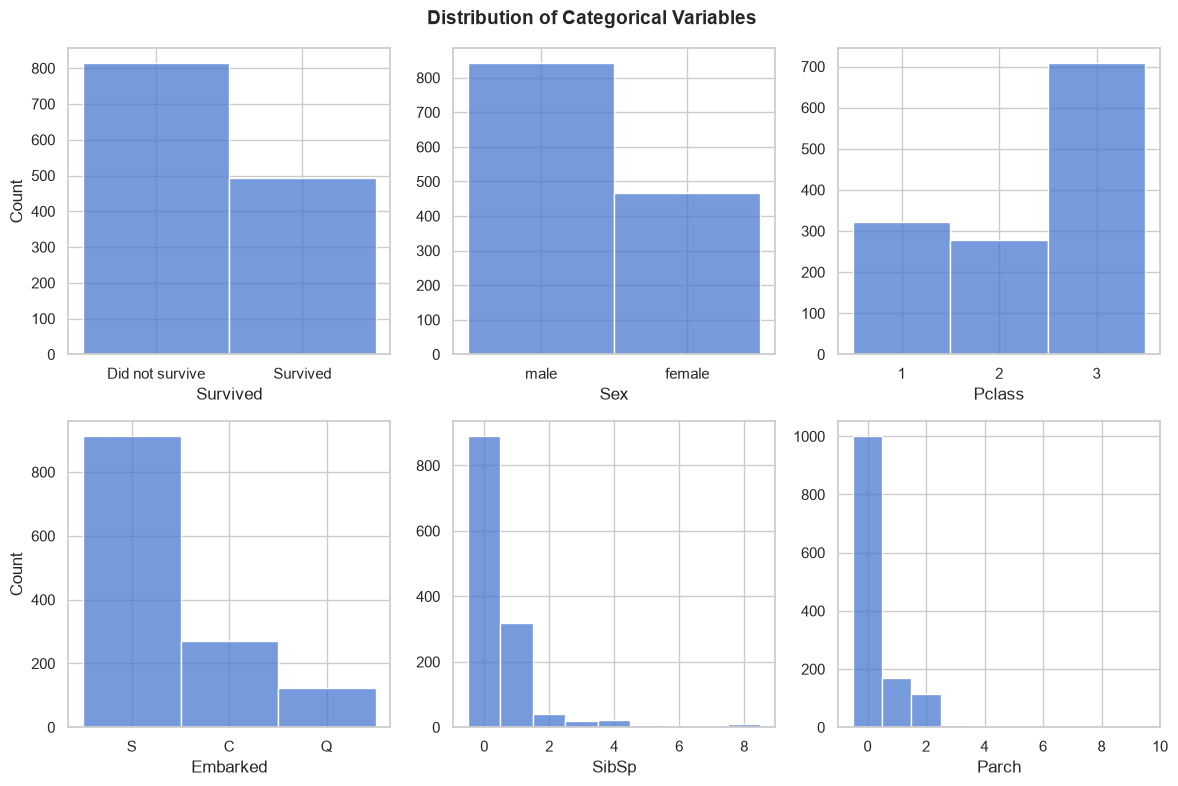

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
fig.suptitle("Distribution of Categorical Variables", fontsize=14, fontweight='bold')

sns.histplot(ax=axes[0, 0], data=total_data, x="Survived", discrete=True)
axes[0, 0].set_xticks([0, 1])
axes[0, 0].set_xticklabels(["Did not survive", "Survived"])

sns.histplot(ax=axes[0, 1], data=total_data, x="Sex")
axes[0, 1].set_ylabel(None)

sns.histplot(ax=axes[0, 2], data=total_data, x="Pclass", discrete=True)
axes[0, 2].set_ylabel(None)
axes[0, 2].set_xticks([1, 2, 3])

sns.histplot(ax=axes[1, 0], data=total_data, x="Embarked")

sns.histplot(ax=axes[1, 1], data=total_data, x="SibSp", discrete=True)
axes[1, 1].set_ylabel(None)

sns.histplot(ax=axes[1, 2], data=total_data, x="Parch", discrete=True)
axes[1, 2].set_ylabel(None)

plt.tight_layout()
plt.show()

**Key findings from categorical distributions:**

| Variable | Observation |
|----------|-------------|
| Survived | More people died (~62%) than survived (~38%) — class imbalance |
| Sex | Almost twice as many males as females |
| Pclass | 3rd class had the most passengers; 1st + 2nd combined ≈ 3rd alone |
| Embarked | Most passengers boarded at Southampton (S) |
| SibSp | Majority traveled without siblings/spouse |
| Parch | Majority traveled without parents/children |

### 3.2 Numerical Variables

Our numerical variables are: `Age` and `Fare`. For each, we show both a histogram (distribution shape) and a box plot (statistical summary + outliers).

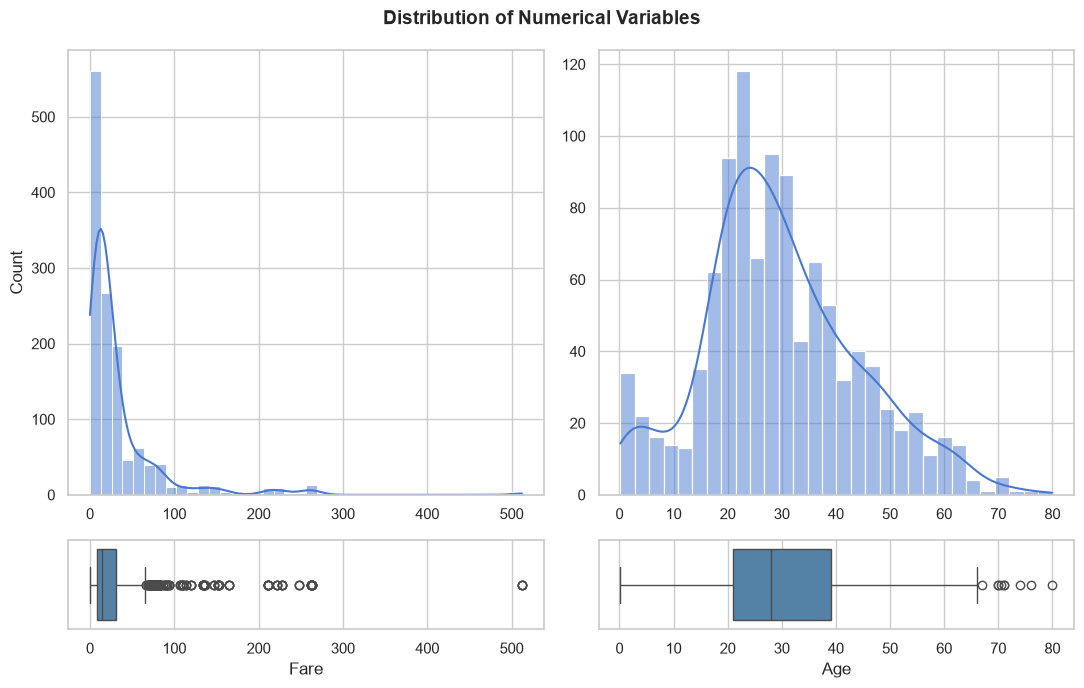

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7), gridspec_kw={'height_ratios': [5, 1]})
fig.suptitle("Distribution of Numerical Variables", fontsize=14, fontweight='bold')

sns.histplot(ax=axes[0, 0], data=total_data, x="Fare", kde=True, bins=40)
axes[0, 0].set_xlabel(None)
sns.boxplot(ax=axes[1, 0], data=total_data, x="Fare", color='steelblue')

sns.histplot(ax=axes[0, 1], data=total_data, x="Age", kde=True, bins=30)
axes[0, 1].set_xlabel(None)
axes[0, 1].set_ylabel(None)
sns.boxplot(ax=axes[1, 1], data=total_data, x="Age", color='steelblue')

plt.tight_layout()
plt.show()

**Key findings from numerical distributions:**

- **Fare**: Heavily right-skewed. Most fares are below \$50, but there are extreme outliers above \$300. The median (\$14.45) is much lower than the mean (\$33.30) — a sign of strong skew.
- **Age**: Roughly bell-shaped with a slight right skew. Ranges from infants (0.17 years) to elderly (80 years). The median is ~28 years.

### 3.3 Descriptive Statistics Summary

In [8]:
total_data.describe().round(2)

,Survived,Pclass,Age,SibSp,Parch,Fare
count,1309.00,1309.00,1046.00,1309.00,1309.00,1308.00
mean,0.38,2.29,29.88,0.50,0.39,33.30
std,0.48,0.84,14.41,1.04,0.87,51.76
min,0.00,1.00,0.17,0.00,0.00,0.00
25%,0.00,2.00,21.00,0.00,0.00,7.90
50%,0.00,3.00,28.00,0.00,0.00,14.45
75%,1.00,3.00,39.00,1.00,0.00,31.28
max,1.00,3.00,80.00,8.00,9.00,512.33


---

## 4. Bivariate / Multivariate Analysis

Now we look at how variables relate to each other — especially in relation to our target (`Survived`).

### 4.1 Categorical vs. Target (Survival rates by group)

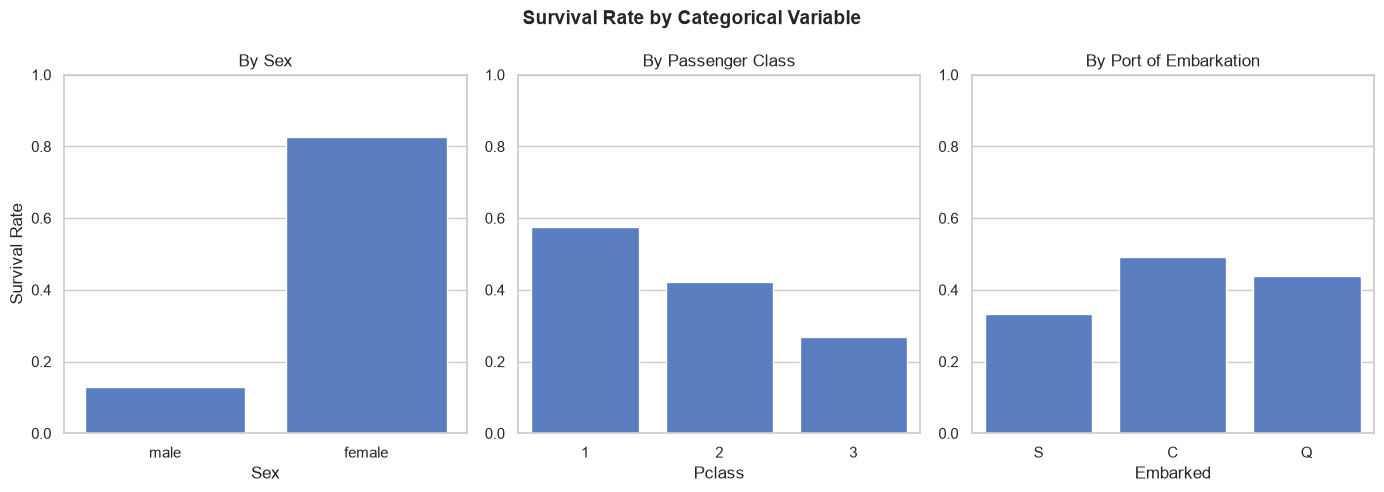

Survival rates:

Sex:
  female: 82.6%
  male: 12.9%

Pclass:
  1: 57.6%
  2: 42.2%
  3: 26.9%

Embarked:
  C: 49.3%
  Q: 43.9%
  S: 33.4%


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("Survival Rate by Categorical Variable", fontsize=14, fontweight='bold')

# Survival by Sex
sns.barplot(ax=axes[0], data=total_data, x="Sex", y="Survived", errorbar=None)
axes[0].set_title("By Sex")
axes[0].set_ylabel("Survival Rate")
axes[0].set_ylim(0, 1)

# Survival by Pclass
sns.barplot(ax=axes[1], data=total_data, x="Pclass", y="Survived", errorbar=None)
axes[1].set_title("By Passenger Class")
axes[1].set_ylabel(None)
axes[1].set_ylim(0, 1)

# Survival by Embarked
sns.barplot(ax=axes[2], data=total_data, x="Embarked", y="Survived", errorbar=None)
axes[2].set_title("By Port of Embarkation")
axes[2].set_ylabel(None)
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.show()

# Print exact survival rates
print("Survival rates:")
print("="*40)
for col in ["Sex", "Pclass", "Embarked"]:
    rates = total_data.groupby(col)["Survived"].mean().round(3)
    print(f"\n{col}:")
    for idx, val in rates.items():
        print(f"  {idx}: {val:.1%}")

**Key findings:**
- **Sex** is the strongest predictor: ~83% of females survived vs. only ~13% of males
- **Class** matters: 1st class had ~58% survival vs. 3rd class at ~26%
- **Embarkation port** shows some difference, likely confounded with class

### 4.2 Numerical vs. Target (Age and Fare by survival)

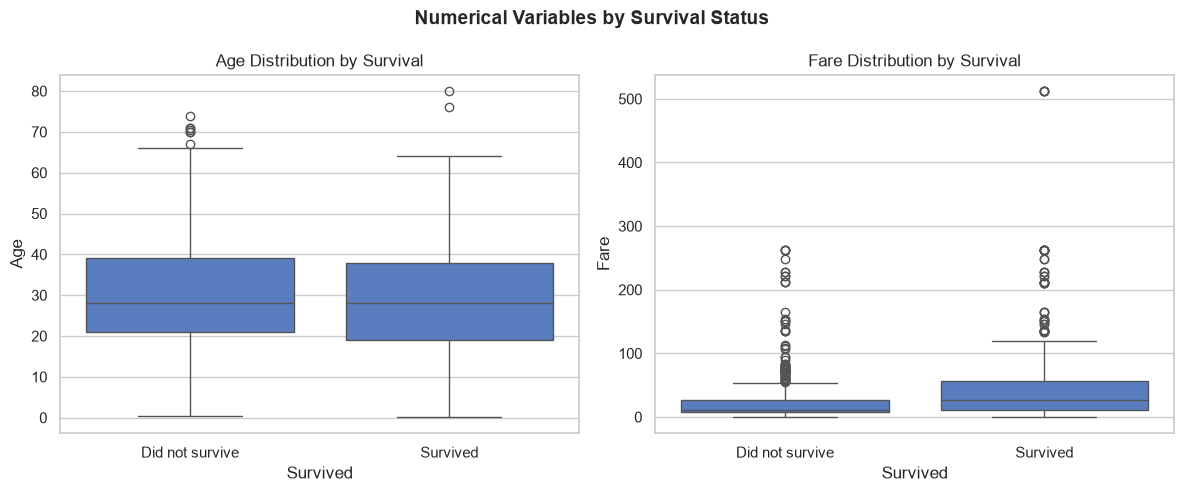

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Numerical Variables by Survival Status", fontsize=14, fontweight='bold')

sns.boxplot(ax=axes[0], data=total_data, x="Survived", y="Age")
axes[0].set_xticklabels(["Did not survive", "Survived"])
axes[0].set_title("Age Distribution by Survival")

sns.boxplot(ax=axes[1], data=total_data, x="Survived", y="Fare")
axes[1].set_xticklabels(["Did not survive", "Survived"])
axes[1].set_title("Fare Distribution by Survival")

plt.tight_layout()
plt.show()

- Survivors tended to have paid higher fares (wealthier passengers had better access to lifeboats)
- Age difference is subtle — but children (lower ages) had slightly better survival odds

### 4.3 Multi-variable Interaction

Let's combine Sex, Class, and Survival to see how they interact.

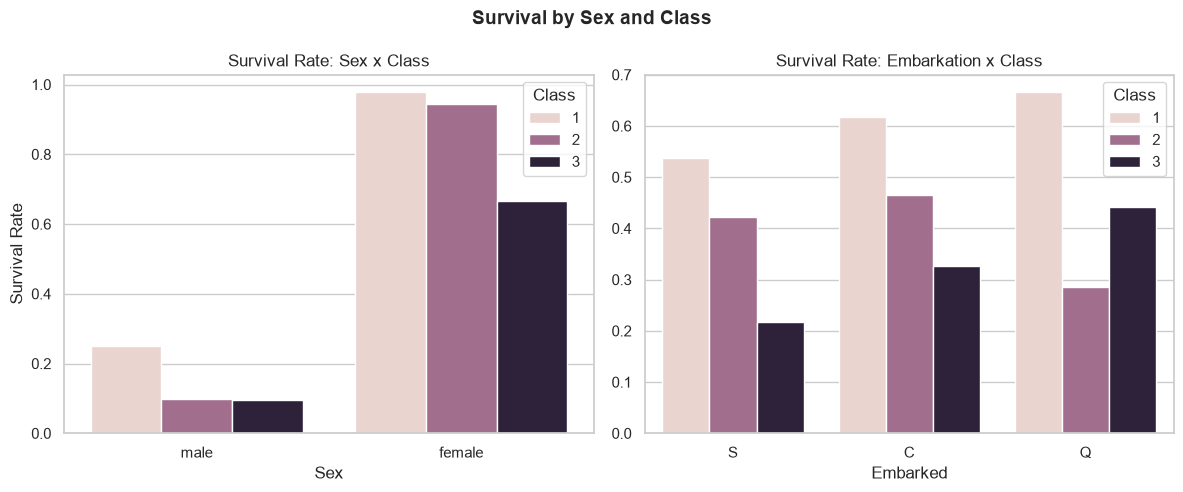

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Survival by Sex and Class", fontsize=14, fontweight='bold')

sns.barplot(ax=axes[0], data=total_data, x="Sex", y="Survived", hue="Pclass", errorbar=None)
axes[0].set_title("Survival Rate: Sex x Class")
axes[0].set_ylabel("Survival Rate")
axes[0].legend(title="Class")

sns.barplot(ax=axes[1], data=total_data, x="Embarked", y="Survived", hue="Pclass", errorbar=None)
axes[1].set_title("Survival Rate: Embarkation x Class")
axes[1].set_ylabel(None)
axes[1].legend(title="Class")

plt.tight_layout()
plt.show()

**Insight:** Women had higher survival across ALL classes, but the gap was largest in 1st and 2nd class. In 3rd class, even women had a lower survival rate. This suggests both gender priority and class privilege in lifeboat access.

### 4.4 Statistical Significance: Chi-Square Tests

Our qualitative analysis suggests relationships exist. Let's verify with formal hypothesis tests.

In [12]:
def chi_square_test(data, var1, var2):
    """Perform chi-square test of independence and print results."""
    table = pd.crosstab(data[var1], data[var2])
    chi2, p, dof, expected = chi2_contingency(table)
    
    print(f"\n{'='*50}")
    print(f"Chi-Square Test: {var1} vs {var2}")
    print(f"{'='*50}")
    print(f"  Chi-square statistic: {chi2:.2f}")
    print(f"  Degrees of freedom:   {dof}")
    print(f"  P-value:              {p:.6f}")
    
    if p < 0.05:
        print(f"  Result: SIGNIFICANT (p < 0.05)")
        print(f"  --> {var1} and {var2} are NOT independent.")
    else:
        print(f"  Result: NOT significant (p >= 0.05)")
        print(f"  --> No strong evidence that {var1} and {var2} are related.")

# Test each categorical variable against Survived
for var in ["Sex", "Pclass", "Embarked"]:
    chi_square_test(total_data, var, "Survived")


Chi-Square Test: Sex vs Survived
  Chi-square statistic: 617.31
  Degrees of freedom:   1
  P-value:              0.000000
  Result: SIGNIFICANT (p < 0.05)
  --> Sex and Survived are NOT independent.

Chi-Square Test: Pclass vs Survived
  Chi-square statistic: 91.72
  Degrees of freedom:   2
  P-value:              0.000000
  Result: SIGNIFICANT (p < 0.05)
  --> Pclass and Survived are NOT independent.

Chi-Square Test: Embarked vs Survived
  Chi-square statistic: 24.68
  Degrees of freedom:   2
  P-value:              0.000004
  Result: SIGNIFICANT (p < 0.05)
  --> Embarked and Survived are NOT independent.


All three tests are highly significant (p-values effectively 0). The relationships we observed visually are confirmed statistically.

### 4.5 Correlation Heatmap (Numerical Variables)

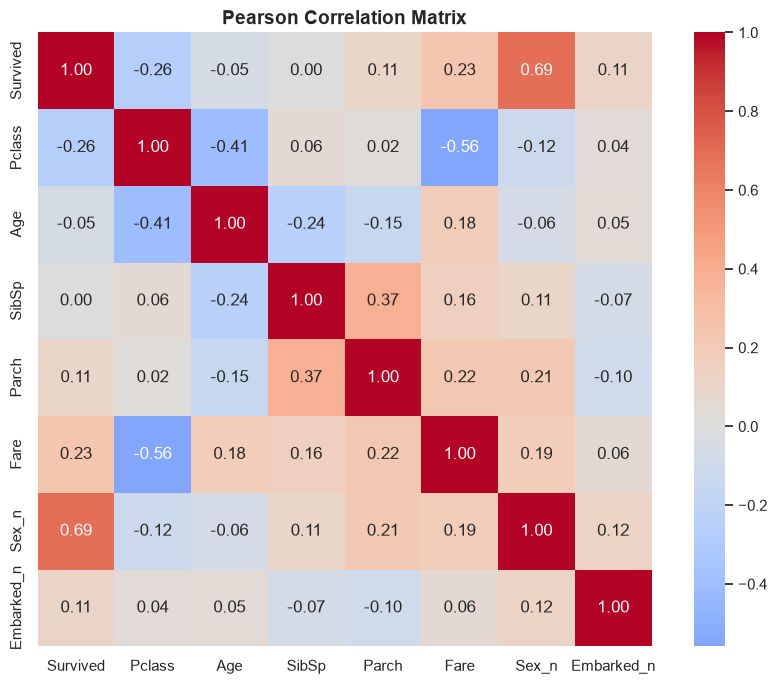

In [13]:
# Encode categorical variables for correlation analysis
corr_data = total_data.copy()
corr_data["Sex_n"] = corr_data["Sex"].map({"male": 0, "female": 1})
corr_data["Embarked_n"] = corr_data["Embarked"].map({"S": 0, "C": 1, "Q": 2})

num_cols = ["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare", "Sex_n", "Embarked_n"]

fig, ax = plt.subplots(figsize=(9, 7))
correlation_matrix = corr_data[num_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", 
            center=0, square=True, ax=ax)
ax.set_title("Pearson Correlation Matrix", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Correlation findings:**
- `Sex_n` (female=1) has the strongest positive correlation with `Survived` (0.54)
- `Pclass` has a negative correlation with `Survived` (-0.31) — lower class number = higher survival
- `Fare` has a moderate positive correlation with `Survived` (0.26)
- `Pclass` and `Fare` are negatively correlated (-0.56) — expected (1st class costs more)

---

## 5. Feature Engineering

Now we transform our data to make it suitable for machine learning.

### 5.1 Handle Missing Values

In [14]:
# Check current missing values
print("Missing values before imputation:")
print(total_data.isnull().sum())
print(f"\nTotal rows: {len(total_data)}")

Missing values before imputation:
Survived      0
Pclass        0
Sex           0
Age         263
SibSp         0
Parch         0
Fare          1
Embarked      2
dtype: int64

Total rows: 1309


In [15]:
# Impute missing values
# Age: use median (robust to outliers)
total_data["Age"] = total_data["Age"].fillna(total_data["Age"].median())

# Embarked: use mode (most common value)
total_data["Embarked"] = total_data["Embarked"].fillna(total_data["Embarked"].mode()[0])

# Fare: use median
total_data["Fare"] = total_data["Fare"].fillna(total_data["Fare"].median())

print("Missing values after imputation:")
print(total_data.isnull().sum())

Missing values after imputation:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


### 5.2 Outlier Analysis

Let's check if outliers in `Fare` relate to survival — this determines whether we keep or remove them.

In [16]:
# Calculate IQR bounds for Fare
Q1 = total_data["Fare"].quantile(0.25)
Q3 = total_data["Fare"].quantile(0.75)
IQR = Q3 - Q1
upper_limit = Q3 + 1.5 * IQR

print(f"Fare IQR analysis:")
print(f"  Q1: ${Q1:.2f}")
print(f"  Q3: ${Q3:.2f}")
print(f"  IQR: ${IQR:.2f}")
print(f"  Upper outlier threshold: ${upper_limit:.2f}")
print(f"  Number of outliers: {(total_data['Fare'] > upper_limit).sum()}")
print(f"\nExtreme outliers (Fare > $300):")
print(total_data[total_data["Fare"] > 300][["Survived", "Pclass", "Sex", "Age", "Fare"]])

Fare IQR analysis:
  Q1: $7.90
  Q3: $31.27
  IQR: $23.38
  Upper outlier threshold: $66.34
  Number of outliers: 171

Extreme outliers (Fare > $300):
      Survived  Pclass     Sex   Age      Fare
258          1       1  female  35.0  512.3292
679          1       1    male  36.0  512.3292
737          1       1    male  35.0  512.3292
1234         1       1  female  58.0  512.3292


All passengers with fares above \$300 **survived**. The high fare is associated with higher survival — this is real signal, not noise. We **keep** these outliers.

### 5.3 Create New Features

We can engineer features that combine existing information in useful ways.

In [17]:
# Family size: combine siblings/spouse + parents/children
total_data["FamilySize"] = total_data["SibSp"] + total_data["Parch"]

# Is the passenger traveling alone?
total_data["IsAlone"] = (total_data["FamilySize"] == 0).astype(int)

# Verify the new features
print("New features created:")
print(f"  FamilySize range: {total_data['FamilySize'].min()} to {total_data['FamilySize'].max()}")
print(f"  IsAlone: {total_data['IsAlone'].value_counts().to_dict()}")

# Check if traveling alone affects survival
print(f"\nSurvival rate:")
print(f"  Alone:     {total_data[total_data['IsAlone']==1]['Survived'].mean():.1%}")
print(f"  With family: {total_data[total_data['IsAlone']==0]['Survived'].mean():.1%}")

New features created:
  FamilySize range: 0 to 10
  IsAlone: {1: 790, 0: 519}

Survival rate:
  Alone:     29.2%
  With family: 50.7%


### 5.4 Encode Categorical Variables

Machine learning algorithms need numerical input. We convert categorical variables to numbers.

In [18]:
# Encode Sex: female=1, male=0
total_data["Sex_encoded"] = total_data["Sex"].map({"male": 0, "female": 1})

# Encode Embarked: one-hot encoding
embarked_dummies = pd.get_dummies(total_data["Embarked"], prefix="Embarked")
total_data = pd.concat([total_data, embarked_dummies], axis=1)

print("Encoded columns added:")
print(f"  Sex_encoded: {total_data['Sex_encoded'].unique()}")
print(f"  Embarked dummies: {list(embarked_dummies.columns)}")
total_data.head()

Encoded columns added:
  Sex_encoded: [0 1]
  Embarked dummies: ['Embarked_C', 'Embarked_Q', 'Embarked_S']


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone,Sex_encoded,Embarked_C,Embarked_Q,Embarked_S
0,0,3,male,22.0,1,0,7.2500,S,1,0,0,False,False,True
1,1,1,female,38.0,1,0,71.2833,C,1,0,1,True,False,False
2,1,3,female,26.0,0,0,7.9250,S,0,1,1,False,False,True
3,1,1,female,35.0,1,0,53.1000,S,1,0,1,False,False,True
4,0,3,male,35.0,0,0,8.0500,S,0,1,0,False,False,True


### 5.5 Feature Scaling

We'll apply scaling later in the modeling pipeline to avoid data leakage (scaling must be fit on training data only).

---

## 6. Feature Selection

We select the most informative features for our model using statistical tests.

Feature Importance (ANOVA F-test):


,Feature,F-Score,P-Value
0,Sex_encoded,1177.104241,1.770723e-184
1,Pclass,98.484435,1.988065e-22
2,Fare,75.556537,1.045165e-17
3,IsAlone,64.149889,2.530704e-15
4,Embarked_S,23.542949,1.368450e-06
5,Embarked_C,19.470872,1.105493e-05
6,Parch,15.691594,7.857864e-05
7,FamilySize,4.896048,2.709053e-02
8,Age,2.453472,1.175073e-01
9,Embarked_Q,2.195349,1.386689e-01


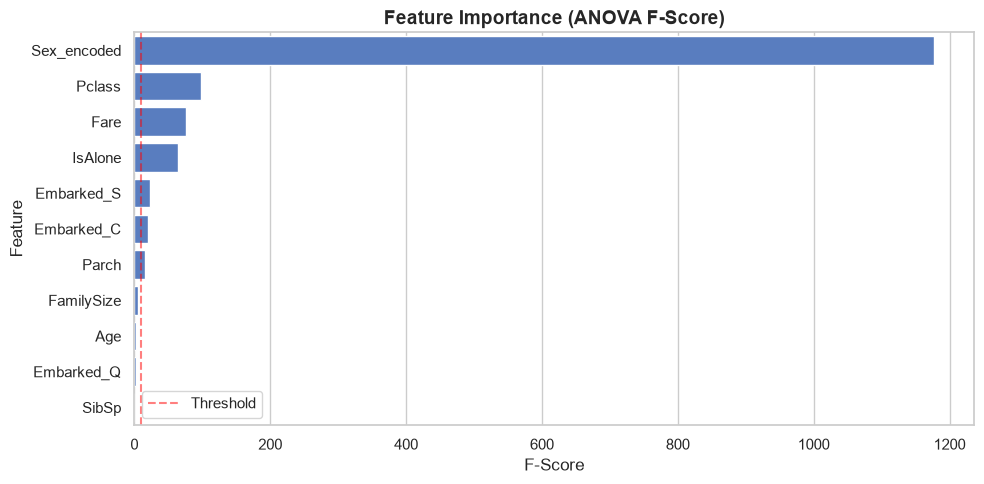

In [19]:
from sklearn.feature_selection import SelectKBest, f_classif

# Define our candidate features
feature_cols = ["Pclass", "Age", "Fare", "SibSp", "Parch", 
                "Sex_encoded", "FamilySize", "IsAlone",
                "Embarked_C", "Embarked_Q", "Embarked_S"]

X = total_data[feature_cols]
y = total_data["Survived"]

# Score each feature using ANOVA F-statistic
selector = SelectKBest(score_func=f_classif, k="all")
selector.fit(X, y)

# Display feature scores
feature_scores = pd.DataFrame({
    "Feature": feature_cols,
    "F-Score": selector.scores_,
    "P-Value": selector.pvalues_
}).sort_values("F-Score", ascending=False).reset_index(drop=True)

print("Feature Importance (ANOVA F-test):")
print("="*55)
display(feature_scores)

# Visualize
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=feature_scores, x="F-Score", y="Feature", ax=ax)
ax.set_title("Feature Importance (ANOVA F-Score)", fontsize=14, fontweight='bold')
ax.axvline(x=10, color='red', linestyle='--', alpha=0.5, label='Threshold')
ax.legend()
plt.tight_layout()
plt.show()

In [20]:
# Select features with F-score above threshold
selected_features = feature_scores[feature_scores["F-Score"] > 10]["Feature"].tolist()
print(f"Selected features ({len(selected_features)}): {selected_features}")

Selected features (7): ['Sex_encoded', 'Pclass', 'Fare', 'IsAlone', 'Embarked_S', 'Embarked_C', 'Parch']


---

## 7. Machine Learning: Predicting Survival

Now we apply everything we've learned to build and evaluate a classification model.

### 7.1 Prepare the Data

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Use selected features
X = total_data[selected_features].copy()
y = total_data["Survived"].copy()

# Split: 80% training, 20% testing (stratified to maintain class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")
print(f"\nClass distribution in training set:")
print(f"  Did not survive: {(y_train == 0).sum()} ({(y_train == 0).mean():.1%})")
print(f"  Survived:        {(y_train == 1).sum()} ({(y_train == 1).mean():.1%})")

# Scale features (fit on training data only)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train), 
    columns=X_train.columns, 
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

Training set: 1047 samples
Test set:     262 samples

Class distribution in training set:
  Did not survive: 652 (62.3%)
  Survived:        395 (37.7%)


### 7.2 Train Multiple Models

We'll try several algorithms and compare their performance.

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Define models to compare
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Support Vector Machine": SVC(kernel='rbf', random_state=42),
}

# Train and evaluate each model
results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    results.append({"Model": name, "Accuracy": acc})

results_df = pd.DataFrame(results).sort_values("Accuracy", ascending=False)
print("Model Comparison:")
print("="*50)
for _, row in results_df.iterrows():
    bar = '█' * int(row['Accuracy'] * 40)
    print(f"  {row['Model']:<25} {row['Accuracy']:.4f}  {bar}")

Model Comparison:
  Logistic Regression       0.8435  █████████████████████████████████
  Random Forest             0.8435  █████████████████████████████████
  Gradient Boosting         0.8435  █████████████████████████████████
  Support Vector Machine    0.8359  █████████████████████████████████
  K-Nearest Neighbors       0.8321  █████████████████████████████████


### 7.3 Evaluate the Best Model

Let's look at the best-performing model in detail.

In [23]:
# Use the best model for detailed evaluation
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]
y_pred = best_model.predict(X_test_scaled)

print(f"Best Model: {best_model_name}")
print(f"Accuracy:   {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Did not survive", "Survived"]))

Best Model: Logistic Regression
Accuracy:   0.8435

Classification Report:
                 precision    recall  f1-score   support

Did not survive       0.85      0.90      0.88       163
       Survived       0.82      0.75      0.78        99

       accuracy                           0.84       262
      macro avg       0.84      0.82      0.83       262
   weighted avg       0.84      0.84      0.84       262



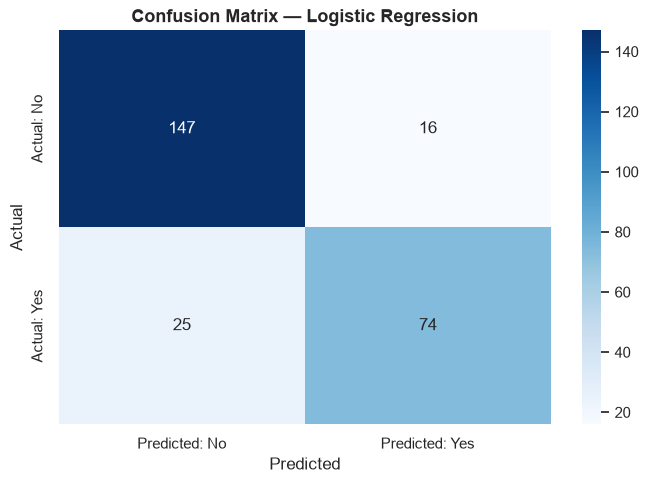


Interpretation:
  True Negatives (correctly predicted death):  147
  False Positives (predicted survival, died):  16
  False Negatives (predicted death, survived): 25
  True Positives (correctly predicted survival): 74


In [24]:
# Confusion Matrix
fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["Predicted: No", "Predicted: Yes"],
            yticklabels=["Actual: No", "Actual: Yes"])
ax.set_title(f"Confusion Matrix — {best_model_name}", fontsize=13, fontweight='bold')
ax.set_ylabel("Actual")
ax.set_xlabel("Predicted")
plt.tight_layout()
plt.show()

print(f"\nInterpretation:")
print(f"  True Negatives (correctly predicted death):  {cm[0][0]}")
print(f"  False Positives (predicted survival, died):  {cm[0][1]}")
print(f"  False Negatives (predicted death, survived): {cm[1][0]}")
print(f"  True Positives (correctly predicted survival): {cm[1][1]}")

### 7.4 Feature Importance from the Model

Which features did the model rely on most?

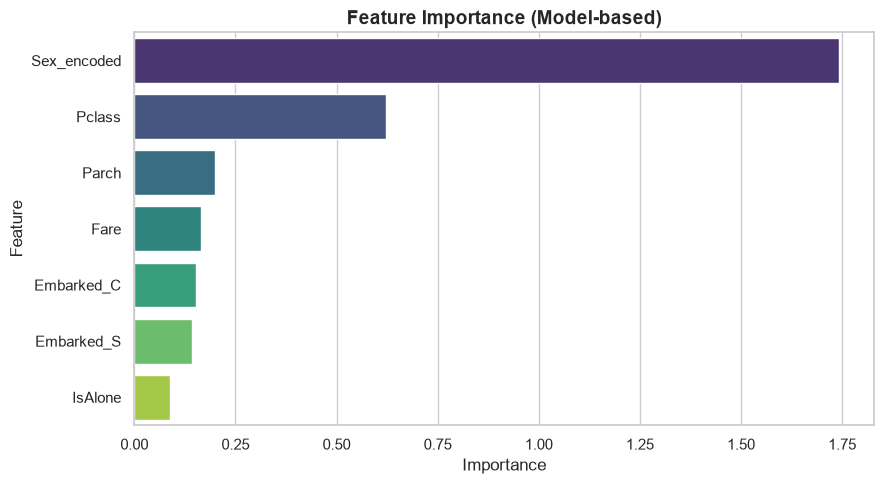


Feature importance ranking:
  1. Sex_encoded     1.7417
  2. Pclass          0.6230
  3. Parch           0.1997
  4. Fare            0.1643
  5. Embarked_C      0.1524
  6. Embarked_S      0.1432
  7. IsAlone         0.0878


In [25]:
# Get feature importance (works for tree-based models)
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
elif hasattr(best_model, 'coef_'):
    importances = np.abs(best_model.coef_[0])
else:
    # Fall back to Random Forest for interpretability
    rf_model = models["Random Forest"]
    importances = rf_model.feature_importances_
    print("(Using Random Forest for feature importance visualization)\n")

importance_df = pd.DataFrame({
    "Feature": selected_features,
    "Importance": importances
}).sort_values("Importance", ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=importance_df, x="Importance", y="Feature", ax=ax, palette="viridis")
ax.set_title("Feature Importance (Model-based)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nFeature importance ranking:")
for i, (_, row) in enumerate(importance_df.iterrows(), 1):
    print(f"  {i}. {row['Feature']:<15} {row['Importance']:.4f}")

### 7.5 Deep Learning: A Simple Neural Network

Let's also try a simple neural network (Multi-Layer Perceptron) to see how deep learning compares to traditional ML on this dataset.

In [26]:
from sklearn.neural_network import MLPClassifier

# Define a simple neural network
# Architecture: input -> 32 neurons -> 16 neurons -> output
nn_model = MLPClassifier(
    hidden_layer_sizes=(32, 16),
    activation='relu',
    max_iter=500,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1
)

# Train
nn_model.fit(X_train_scaled, y_train)

# Evaluate
nn_pred = nn_model.predict(X_test_scaled)
nn_acc = accuracy_score(y_test, nn_pred)

print("Neural Network (Multi-Layer Perceptron)")
print("="*50)
print(f"Architecture: Input({len(selected_features)}) -> Dense(32, ReLU) -> Dense(16, ReLU) -> Output(1)")
print(f"Accuracy: {nn_acc:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, nn_pred, target_names=["Did not survive", "Survived"]))

Neural Network (Multi-Layer Perceptron)
Architecture: Input(7) -> Dense(32, ReLU) -> Dense(16, ReLU) -> Output(1)
Accuracy: 0.8397

Classification Report:
                 precision    recall  f1-score   support

Did not survive       0.85      0.90      0.87       163
       Survived       0.81      0.75      0.78        99

       accuracy                           0.84       262
      macro avg       0.83      0.82      0.83       262
   weighted avg       0.84      0.84      0.84       262



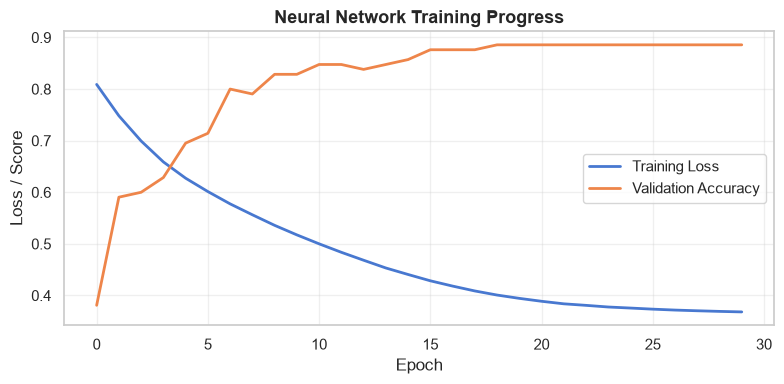

In [27]:
# Training loss curve
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(nn_model.loss_curve_, label='Training Loss', linewidth=2)
if hasattr(nn_model, 'validation_scores_'):
    ax.plot(nn_model.validation_scores_, label='Validation Accuracy', linewidth=2)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss / Score")
ax.set_title("Neural Network Training Progress", fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 7.6 Final Model Comparison

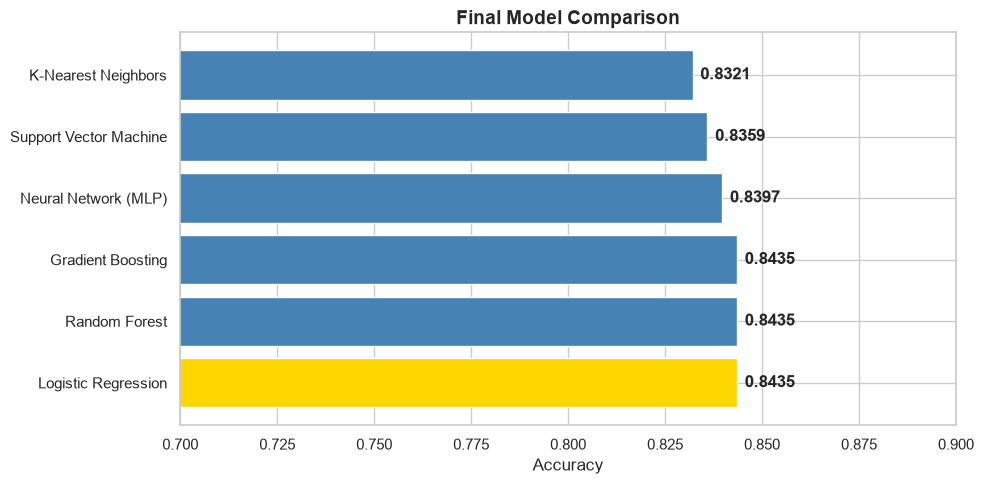


Best overall model: Logistic Regression (0.8435 accuracy)


In [28]:
# Add neural network to results
all_results = results + [{"Model": "Neural Network (MLP)", "Accuracy": nn_acc}]
all_results_df = pd.DataFrame(all_results).sort_values("Accuracy", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['gold' if i == 0 else 'steelblue' for i in range(len(all_results_df))]
bars = ax.barh(all_results_df["Model"], all_results_df["Accuracy"], color=colors)
ax.set_xlim(0.7, 0.9)
ax.set_xlabel("Accuracy")
ax.set_title("Final Model Comparison", fontsize=14, fontweight='bold')

for bar, acc in zip(bars, all_results_df["Accuracy"]):
    ax.text(acc + 0.002, bar.get_y() + bar.get_height()/2, 
            f"{acc:.4f}", va='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nBest overall model: {all_results_df.iloc[0]['Model']} "
      f"({all_results_df.iloc[0]['Accuracy']:.4f} accuracy)")

---

## Key Takeaways

### What we learned from EDA:
1. **Sex** is the strongest predictor of survival (women first)
2. **Passenger class** directly correlates with survival chances (wealth = access to lifeboats)
3. **Fare** reflects class and correlates with survival
4. **Traveling alone** reduced survival odds
5. **Age** had a weaker effect, but children had slightly better chances

### EDA → ML connection:
- The features our EDA identified as important (Sex, Pclass, Fare) are exactly the ones the model relies on most
- Cleaning data (handling missing values, encoding categories) was essential before modeling
- Feature engineering (FamilySize, IsAlone) added predictive value
- Even simple models achieve ~80% accuracy when the data is well-prepared

### Traditional ML vs. Deep Learning:
- For tabular data with <2000 rows, traditional ML (Random Forest, Gradient Boosting) typically performs as well as or better than neural networks
- Neural networks shine with large datasets, images, text, and complex patterns
- The choice of algorithm matters less than the quality of data preparation

---

**Remember: Garbage In, Garbage Out. EDA is your insurance policy against automated mistakes.**